## 1. 데이터 셋팅
### 1-1 분석환경 설정

In [1]:
!pip install pmdarima matplotlib seaborn statsforecast --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 2.3 MB/s eta 0:00:00


In [2]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (23.7 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and direct

In [ ]:
## 위에 설치 이후엔 런타임 -> 세션 다시 시작

In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('fivethirtyeight')

import warnings
warnings.filterwarnings('ignore')
pd.options.display.float_format = '{:.2f}'.format

from pmdarima import auto_arima

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.statespace.tools import diff
from statsmodels.tools.eval_measures import rmse
from statsmodels.tsa.stattools import adfuller
from statsforecast import StatsForecast
import itertools


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
file_path ='/content/drive/MyDrive/'
df= pd.read_csv(file_path + '0727_Seoul_preprocessed.csv',encoding = 'cp949', index_col=0)
df

,기준_년_코드,기준_분기_코드,자치구,행정동,대분류,상권_코드,중분류,업종명,총_점포수,점포_수,순점포증감률,개업_율,개업_점포_수,폐업_률,폐업_점포_수,프랜차이즈_점포_수,총_매출_금액,분기당_매출_금액,주중_매출_금액,주말_매출_금액,남성_매출_금액,여성_매출_금액
0,2022,1,서대문구,북가좌2동,서비스,2110499,의료,한의원,1,1,0.00,0,0,0,0,0,54003138,54003138,35504845,18498293,8791373,45211765
1,2022,1,노원구,공릉1동,소매,2110433,의류/잡화,안경,1,1,0.00,0,0,0,0,0,16150022,16150022,14674653,1475369,9906049,6243973
2,2022,1,마포구,성산1동,소매,2110548,전자기기,컴퓨터및주변장치판매,4,4,0.00,0,0,0,0,0,89813767,89813767,89813767,0,0,89813767
3,2022,1,은평구,대조동,서비스,2110481,미용,피부관리실,3,3,0.33,33,1,0,0,0,4619842,4619842,405102,4214740,405102,4214740
4,2022,1,영등포구,신길6동,서비스,2110804,교육,예술학원,5,5,0.00,0,0,0,0,0,5946480,5946480,5946480,0,0,5946480
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
912344,2017,4,강남구,삼성1동,소매,1001496,가구/인테리어,가구,9,9,0.00,0,0,0,0,0,330320365,330320365,303278487,27041878,114857625,116434465
912345,2017,4,강남구,삼성1동,소매,1001496,가구/인테리어,가전제품,9,9,0.00,0,0,0,0,0,2174589379,2174589379,1601331971,573257408,966992622,787018046
912346,2017,4,강남구,삼성1동,소매,1001496,가구/인테리어,인테리어,4,4,0.00,0,0,0,0,0,2839146155,2839146155,1871616983,967529172,695743479,2021268896
912347,2017,4,강남구,삼성1동,소매,1001496,가구/인테리어,예술품,9,9,0.00,0,0,0,0,0,674145284,674145284,544184202,129961082,155488268,153880451


### 1-2. 아드풀러 함수 정의
- 시계열 데이터가 정상성을 만족하는지(분산과 평균이 일정) 혹은 차분이 필요한지 확인
- 아드풀러 테스트 결과를 라벨링하여 리포트로 함수화 진행

In [4]:
#모델 확인
def adf_test(series,title=''):
    """
    Pass in a time series and an optional title, returns an ADF report
    """
    print(f'아드풀러 검정 결과(ADF Test): {title}')
    result = adfuller(series.dropna(),autolag='AIC') # .dropna() handles differenced data

    labels = ['ADF 통계량','p-value','사용된 시차','관측치 수']
    out = pd.Series(result[0:4],index=labels)

    for key,val in result[4].items():
        out[f'임계값 critical value ({key})']=val

    print(out.to_string())

    if result[1] <= 0.05:
        print("➡️ 이 데이터는 '정상성'을 만족합니다.")
    else:
        print("➡️ 이 데이터는 '비정상성'입니다. (차분 작업 필요!)")

## 2. 데이터 전처리 및 탐색
### 2-1. 분석 대상 데이터 추출
- **신촌동**의 **커피-음료** 데이터를 'df_coffee'라는 이름으로 추출

In [5]:
df_coffee = df[(df['행정동']== '신촌동')&(df['업종명'] == '커피-음료')]
df_coffee['기준년분기'] = df_coffee['기준_년_코드'].astype(str) + "-" + df_coffee['기준_분기_코드'].astype(str)
df_coffee= df_coffee.groupby(['기준년분기'])[['주중_매출_금액', '주말_매출_금액']].sum().reset_index()
df_coffee['총매출'] = df_coffee['주중_매출_금액'] + df_coffee['주말_매출_금액']
df_coffee = df_coffee.drop(['주중_매출_금액', '주말_매출_금액'], inplace=False, axis=1)

### 2-2. 시계열 정상성 검증(adf 검정)
- p-value가 0.05보다 크므로 차분이 필요함

In [6]:
adf_test(df_coffee['총매출'], title='신촌 커피-음료 총매출 데이터')

아드풀러 검정 결과(ADF Test): 신촌 커피-음료 총매출 데이터
ADF 통계량                    -2.50
p-value                     0.12
사용된 시차                      8.00
관측치 수                      15.00
임계값 critical value (1%)    -3.96
임계값 critical value (5%)    -3.08
임계값 critical value (10%)   -2.68
➡️ 이 데이터는 '비정상성'입니다. (차분 작업 필요!)


## 3. SARIMA 및 SARIMAX 모델링
- **SARIMA/SARIMAX:** 시계열 데이터의 추세와 오차, 주기적인 계절성을 학습하는
전통 통계 모델. 여기에 외생변수를 결합한 모델이 SARIMAX 입니다.

- **모델 선정 이유:**
    - 1️⃣뚜렷한 계절성이 존재함
    - 2️⃣차분을 통해 비정상성이 큰  매출 데이터를  안정적인 시계열로 변환 후 학습 가능
    - 3️⃣외부변수 주입으로 코로나 왜곡을 방지함

### 3-1. SARIMA 검증

In [7]:
# 데이터를 train(~21년 4분기), test(22년 1~4분기)로 분리합니다.
df_s_base = df_coffee.copy()
train_s_base = df_s_base.iloc[:20]
test_s_base = df_s_base.iloc[20:]

# train 데이터로 autoarima를 실행합니다.
step_model = auto_arima(
    train_s_base['총매출'],
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    d=None,
    seasonal=True,
    m=4,
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    D=None,
    trace=True,
    suppress_warnings=True
)

print(step_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,1,0)[4] intercept   : AIC=735.417, Time=0.19 sec
 ARIMA(1,0,0)(1,1,0)[4] intercept   : AIC=743.812, Time=0.31 sec
 ARIMA(0,0,1)(0,1,1)[4] intercept   : AIC=732.361, Time=0.13 sec
 ARIMA(0,0,0)(0,1,0)[4]             : AIC=743.352, Time=0.03 sec
 ARIMA(0,0,1)(0,1,0)[4] intercept   : AIC=733.631, Time=0.13 sec
 ARIMA(0,0,1)(1,1,1)[4] intercept   : AIC=734.349, Time=0.16 sec
 ARIMA(0,0,1)(0,1,2)[4] intercept   : AIC=733.054, Time=0.14 sec
 ARIMA(0,0,1)(1,1,0)[4] intercept   : AIC=732.519, Time=0.09 sec
 ARIMA(0,0,1)(1,1,2)[4] intercept   : AIC=734.682, Time=0.75 sec
 ARIMA(0,0,0)(0,1,1)[4] intercept   : AIC=732.792, Time=0.21 sec
 ARIMA(1,0,1)(0,1,1)[4] intercept   : AIC=735.878, Time=0.25 sec
 ARIMA(0,0,2)(0,1,1)[4] intercept   : AIC=733.327, Time=0.07 sec
 ARIMA(1,0,0)(0,1,1)[4] intercept   : AIC=743.945, Time=0.05 sec
 ARIMA(1,0,2)(0,1,1)[4] intercept   : AIC=733.661, Time=0.13 sec
 ARIMA(0,0,1)(0,1,1)[4]             : AIC=742.3

#### 📊 auto_arima 결과
- (0,0,1)(0,1,1)[4]으로 지난 분기에 발생한 예측 오차와 계절성 차분과 계절성오차가 반영이 됨
- 20개 분기라는 데이터의 한계로 통계적 유의성 확보 및 잔차의 독립성 분리에는 구조적 제약이 존재함을 인지하고 분석을 진행함

In [8]:
best_order = (0, 0, 1)
best_seasonal_order = (0, 1, 1, 4)

# 검증용 모델 학습
val_model = SARIMAX(
    train_s_base['총매출'].values,
    order=best_order,
    seasonal_order=best_seasonal_order
)
val_results = val_model.fit(disp=False)

# 2022년 1~4분기 예측 수행
start = len(train_s_base)
end = len(train_s_base) + len(test_s_base) - 1
val_predictions = val_results.predict(start=start, end=end)

# 검증 결과 데이터프레임 생성
pred_val_df = pd.DataFrame({
    '기준년분기': test_s_base['기준년분기'].values,
    '실제_총매출': test_s_base['총매출'].values.astype(float),
    '예측_총매출': val_predictions
})

# 평균 분기별 예측 오차율(MAPE)로 오차율 계산 진행
pred_val_df['오차율(%)'] = (abs(pred_val_df['실제_총매출'] - pred_val_df['예측_총매출']) / pred_val_df['실제_총매출']) * 100

print(pred_val_df.to_string(index=False))

# 최종 평균 오차율 (MAPE)
mape = pred_val_df['오차율(%)'].mean()
print(f"\n📉 평균 분기별 예측 오차율(MAPE): {mape:.2f}%")

 기준년분기         실제_총매출        예측_총매출  오차율(%)
2022-1  6499152739.00 5784211481.85   11.00
2022-2  9352509875.00 7443863919.62   20.41
2022-3  9566330395.00 6738421736.93   29.56
2022-4 10313798137.00 7154613372.84   30.63

📉 평균 분기별 예측 오차율(MAPE): 22.90%


### 3-2 SARIMAX 모델 검증
- 외부 변수 추가: ['is_corona']라는 코로나 변수를 추가해서 검증


In [9]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
df_s_exog = df_coffee.copy()
train_s_exog = df_s_exog.iloc[:20]
test_s_exog = df_s_exog.iloc[20:]

# Train 데이터 코로나 변수 생성 (2020년 1분기~2021년 4분기 = 코로나(인덱스 12부터 19까지)
train_s_exog['is_corona'] = 0
train_s_exog.loc[12:19, 'is_corona'] = 1

# Test 데이터 코로나 변수 생성
test_s_exog['is_corona'] = 0

step_model = auto_arima(
    train_s_exog['총매출'],
    X=train_s_exog[['is_corona']],
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    d=None,
    seasonal=True,
    m=4,
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    D=None,
    trace=True,
    suppress_warnings=True
)

print(step_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[4] intercept   : AIC=967.813, Time=0.03 sec
 ARIMA(1,0,0)(1,0,0)[4] intercept   : AIC=937.250, Time=0.66 sec
 ARIMA(0,0,1)(0,0,1)[4] intercept   : AIC=957.095, Time=0.15 sec
 ARIMA(0,0,0)(0,0,0)[4]             : AIC=1024.546, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[4] intercept   : AIC=939.646, Time=0.03 sec
 ARIMA(1,0,0)(2,0,0)[4] intercept   : AIC=939.206, Time=0.13 sec
 ARIMA(1,0,0)(1,0,1)[4] intercept   : AIC=939.109, Time=0.22 sec
 ARIMA(1,0,0)(0,0,1)[4] intercept   : AIC=937.227, Time=0.07 sec
 ARIMA(1,0,0)(0,0,2)[4] intercept   : AIC=939.050, Time=0.17 sec
 ARIMA(1,0,0)(1,0,2)[4] intercept   : AIC=941.012, Time=0.31 sec
 ARIMA(0,0,0)(0,0,1)[4] intercept   : AIC=962.929, Time=0.05 sec
 ARIMA(2,0,0)(0,0,1)[4] intercept   : AIC=940.245, Time=0.33 sec
 ARIMA(1,0,1)(0,0,1)[4] intercept   : AIC=940.596, Time=0.19 sec
 ARIMA(2,0,1)(0,0,1)[4] intercept   : AIC=940.902, Time=0.24 sec
 ARIMA(1,0,0)(0,0,1)[4]             : AIC=934.

### 📊 auto_arima 결과
- SARIMAX(1, 0, 0)x(1, 0, 0, 4) 직전 분기 추세와 작년 동분기 매출 주기가  현재 매출에 인과관계를 가짐
- 외생변수 효과로 차분이 없이도 변동을 학습하여서 모든변수 유의성 확보
- 코로나 변수 덕분에 오차의 미세 패턴은 완전히 제거(Prob(Q)=0.61)되었으나, 오차의 정규성 분포(Prob(JB)=0.00)는 왜곡됨

In [10]:
best_order = (1, 0, 0)
best_seasonal_order = (1, 0, 0, 4)

val_model = SARIMAX(
    train_s_exog['총매출'].values,
    exog=train_s_exog['is_corona'].values,
    order=best_order,
    seasonal_order=best_seasonal_order
)
val_results = val_model.fit(disp=False)

start = len(train_s_exog)
end = len(train_s_exog) + len(test_s_exog) - 1

# 외부변수 값을 행렬 형태로 변환
test_exog = test_s_exog['is_corona'].values.reshape(-1, 1)

val_predictions = val_results.predict(
    start=start,
    end=end,
    exog=test_exog
)

pred_val_df = pd.DataFrame({
    '기준년분기': test_s_exog['기준년분기'].values,
    '실제_총매출': test_s_exog['총매출'].values.astype(float),
    '예측_총매출': val_predictions
})

pred_val_df['오차율(%)'] = (abs(pred_val_df['실제_총매출'] - pred_val_df['예측_총매출']) / pred_val_df['실제_총매출']) * 100
print(pred_val_df.to_string(index=False))

# 최종 평균 오차율 (MAPE)
mape = pred_val_df['오차율(%)'].mean()
print(f"\n📉 평균 분기별 예측 오차율(MAPE): {mape:.2f}%")

 기준년분기         실제_총매출        예측_총매출  오차율(%)
2022-1  6499152739.00 -420868319.81  106.48
2022-2  9352509875.00  425870848.74   95.45
2022-3  9566330395.00   83126442.32   99.13
2022-4 10313798137.00  211293446.62   97.95

📉 평균 분기별 예측 오차율(MAPE): 99.75%


📊 SARIMA/SARIMAX 모델 분석 결과
- 외부 변수 도입 후 오차율이 대폭 상승함(22.90%➡️99.75%)
- 모델이 과거 코로나 시기의 매출 하락을 지나치게 학습하여 과적합 발생
- 코로나 변수를 통해 통계적 유의성은 확보했으나, 엔데믹으로 회복세를 가지는 22년도의 매출 스케일을 따라가지 못하고 음수등의 비현실적인 예측치를 도출함


## 4 Prophet 모델링
- 데이터를 [트렌드, 계절성, 이벤트]라는 독립된 구성 요소로 분해한 뒤, 이를 합산하는 곡선 피팅 방식으로 미래를 예측하는 모델

- **Prophet 선정 이유:**
    - 1️⃣적은데이터 수에 대한 유연함
    - 2️⃣과거 데이터 의존하지 않고, 가장 잘 맞는 곡선을 찾아내는 곡선 피팅 방식
    - 3️⃣외부 변수('is_corona')의 독립적  분리 가능
### 4-1 Prophet 검증

In [6]:
from prophet import Prophet

df_p_base = df_coffee.copy()

# ds(날짜)와 y(예측값) 열을 생성
df_p_base['ds'] = pd.to_datetime(df_coffee['기준년분기'].str.replace('-', 'Q'))
df_p_base['y'] = df_coffee['총매출']

# Train / Test 분할 (앞서 사용한 20개 분기 학습, 이후 테스트)
train_p_base = df_p_base.iloc[:20]
test_p_base = df_p_base.iloc[20:]

# 모델 설정 및 학습
model_base = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model_base.fit(train_p_base)

# 예측 수행
future_base = df_p_base[['ds']]
forecast_base = model_base.predict(future_base)
# 결과 시각화 및 오차 확인
pred_vals_base = forecast_base.iloc[20:]['yhat']

pred_df_base = pd.DataFrame({
    '기준년분기': test_p_base['기준년분기'].values,
    '실제_총매출': test_p_base['y'].values,
    '예측_총매출': pred_vals_base.values
})

pred_df_base['오차율(%)'] = (abs(pred_df_base['실제_총매출'] - pred_df_base['예측_총매출']) / pred_df_base['실제_총매출']) * 100
print(pred_df_base.to_string(index=False))

mape_base = pred_df_base['오차율(%)'].mean()
print(f"\n📉 평균 분기별 예측 오차율(MAPE): {mape_base:.2f}%")


INFO:prophet:n_changepoints greater than number of observations. Using 15.


 기준년분기      실제_총매출          예측_총매출  오차율(%)
2022-1  6499152739 3731461056.6265 42.5854
2022-2  9352509875 6137309726.3274 34.3779
2022-3  9566330395 5428076200.3244 43.2585
2022-4 10313798137 5571109717.3868 45.9839

📉 평균 분기별 예측 오차율(MAPE): 41.55%


### 📊 검증 결과 및 해석
- **결과:** 일반적인 Prophet 모델 평균 분기별 예측 오차율 41.55%
- **해석:** 코로나의 매출 하락세를 따로 설정하지 않아서 일반적인 트렌드로 오인하여 예측함

- **다음 단계:** 코로나 외부변수를 설정하여 일반적인 매출트렌드와 분리

### 4-2 Prophet 모델 + 외부 변수 추가
- 코로나 시기의 매출 하락세를 일반적인 트렌드와 분리하기 위해 'is_corona'라는 외부 변수를 생성

In [7]:
# 데이터프레임 구성
df_p_reg = df_coffee.copy()
df_p_reg['ds'] = pd.to_datetime(df_coffee['기준년분기'].str.replace('-', 'Q'))
df_p_reg['y'] = df_coffee['총매출']

# Train / Test 분할
train_p_reg = df_p_reg.iloc[:20]
test_p_reg = df_p_reg.iloc[20:]

# 코로나 외부 변수 생성
train_p_reg['is_corona'] = 0
train_p_reg.iloc[12:20, train_p_reg.columns == 'is_corona'] = 1
test_p_reg['is_corona'] = 0

# 모델 정의 및 학습
model_reg = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)
model_reg.add_regressor('is_corona')
model_reg.fit(train_p_reg)

# 예측용 미래 데이터프레임 만들기
future_reg = pd.concat([train_p_reg[['ds', 'is_corona']], test_p_reg[['ds', 'is_corona']]], axis=0).reset_index(drop=True)
forecast_reg = model_reg.predict(future_reg)

# Test 예측값 추출
pred_vals_reg = forecast_reg.iloc[20:]['yhat']

# 결과 비교 데이터프레임 생성 및 MAPE 계산
pred_df_reg = pd.DataFrame({
    '기준년분기': test_p_reg['기준년분기'].values,
    '실제_총매출': test_p_reg['y'].values,
    '예측_총매출': pred_vals_reg.values
})

pred_df_reg['오차율(%)'] = (abs(pred_df_reg['실제_총매출'] - pred_df_reg['예측_총매출']) / pred_df_reg['실제_총매출']) * 100
print(pred_df_reg.to_string(index=False))

mape_reg = pred_df_reg['오차율(%)'].mean()
print(f"\n📉 평균 분기별 예측 오차율(MAPE): {mape_reg:.2f}%")

INFO:prophet:n_changepoints greater than number of observations. Using 15.


 기준년분기      실제_총매출          예측_총매출  오차율(%)
2022-1  6499152739 6286839524.9654  3.2668
2022-2  9352509875 8475845189.1152  9.3736
2022-3  9566330395 7736799767.1177 19.1247
2022-4 10313798137 7919453649.9173 23.2150

📉 평균 분기별 예측 오차율(MAPE): 13.75%


### 📊 검증 결과 및 해석
- **결과:** 코로나라는 변수 분리로 오차율 급감 (41.55% ➡️ 13.75%)
- **해석:** 코로나 시기의 하락  트렌드를 분리하여 예측 정확도  상승
- **다음 단계:** 최종 Prophet모델링과 그래프 시각화

## 5. 2023년 미래 예측
- 오차율이 가장 적은 Prophet(+외부변수)모델로 2023년 예측 진행
- 기존 매출과 예측한 값 시각화 진행

In [10]:
# 전체 데이터 프레임에 코로나 외부 변수 컬럼 생성
df_p_reg['is_corona'] = 0
df_p_reg.loc[12:20, 'is_corona'] = 1

# 전체 데이터 이용하여 재학습
model_reg = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)
model_reg.add_regressor('is_corona')
model_reg.fit(df_p_reg)

# 예측할 미래 날짜 데이터프레임 생성
future_dates = pd.DataFrame({
    'ds': pd.to_datetime(['2023-03-31', '2023-06-30', '2023-09-30', '2023-12-31']),
    'is_corona': [0, 0, 0, 0]
})

# 과거 학습 데이터와 미래 예측 데이터를 위아래로 결합
future_2023 = pd.concat([df_p_reg[['ds', 'is_corona']], future_dates], axis=0).reset_index(drop=True)

# 2023년 미래 예측 수행
forecast_2023 = model_reg.predict(future_2023)

# 미래 4분기 데이터프레임을 분리
forecast_real = forecast_2023.tail(4)[['ds', 'yhat']].reset_index(drop=True)

# 출력용 컬럼명 및 분기 텍스트 매핑
forecast_real.columns = ['기준년분기', '2023년_예측_총매출']
forecast_real['기준년분기'] = ['2023-1', '2023-2', '2023-3', '2023-4']

# 원 단위 금액 콤마(,) 표기 설정
pd.options.display.float_format = '{:,.0f}'.format

print("============ Prophet 기반 2023년 미래 매출 예측 ============")
print(forecast_real.to_string(index=False))

INFO:prophet:n_changepoints greater than number of observations. Using 18.


============ Prophet 기반 2023년 미래 매출 예측 ============
 기준년분기  2023년_예측_총매출
2023-1 6,187,115,182
2023-2 8,574,267,865
2023-3 7,780,307,631
2023-4 8,884,267,712


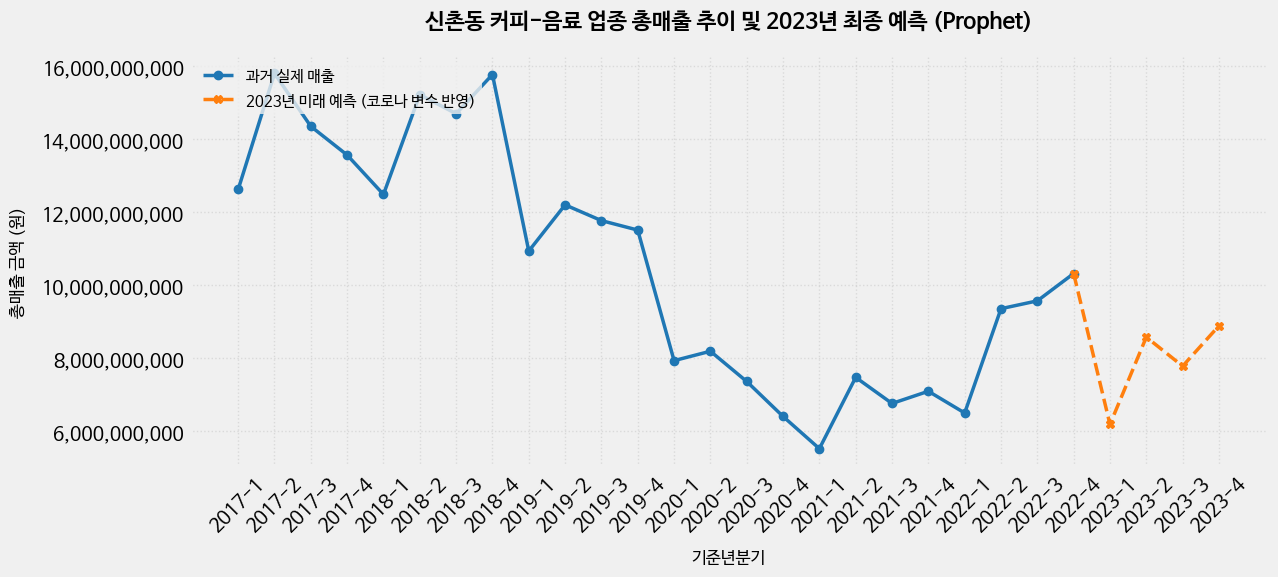

In [9]:
import matplotlib.ticker as ticker
from matplotlib import rc

# 그래프 크기 설정
plt.figure(figsize=(13, 6))

# 과거 실제 데이터 그리기 (17년 1분기 ~ 22년 4분기)
plt.plot(df_coffee['기준년분기'], df_coffee['총매출'], marker='o',
         label='과거 실제 매출', color='#1f77b4', linewidth=2.5)

# 2023년 예측 데이터 그리기 (22년 4분기 마지막 점과 자연스럽게 연결)
last_actual_time = df_coffee['기준년분기'].iloc[-1]
last_actual_value = df_coffee['총매출'].iloc[-1]

forecast_x = [last_actual_time] + forecast_real['기준년분기'].tolist()
forecast_y = [last_actual_value] + forecast_real['2023년_예측_총매출'].tolist()

# 예측 구간은 주황색 점선(--)과 X 마커로 직관적 표시
plt.plot(forecast_x, forecast_y, marker='X', linestyle='--',
         label='2023년 미래 예측 (코로나 변수 반영)', color='#ff7f0e', linewidth=2.5)

# 그래프 레이아웃 및 디자인 다듬기
plt.title('신촌동 커피-음료 업종 총매출 추이 및 2023년 최종 예측 (Prophet)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('기준년분기', fontsize=12, labelpad=10)
plt.ylabel('총매출 금액 (원)', fontsize=12, labelpad=10)
plt.xticks(rotation=45)

# Y축 금액 축 단위 쉼표(,) 표현 버그 완벽 차단 (StrMethodFormatter 활용)
# 기존 set_yticklabels 방식 대신 Matplotlib 정석 라이브러리를 써서 억 단위 금액도 안 깨지게 만듭니다.
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='upper left', edgecolor='none')
plt.tight_layout()
plt.show()

### 📊 결과 및 해석
- 직전 연도의 트렌드인 회복세를 반영하여 반등하는 흐름을 예측함

## 6. 서울시 행정동 모델링 적용

서울 전체 행정동(389개)를 대상으로 [커피-음료] 업종 매출 예측 모델링 진행
- **목표:** 현재 데이터로 예측 가능한 행정동과 불가능한 행정동을 분리함
- **모델링:** 전체 행정동에서 가장 오차율이 적게 나왔던 Prophet (+외부변수) 모델을 이용
- **과정** 평균 분기별 오차율(MAPE)을 이용하여 오차율 등급  설정


In [47]:
import os
import sys
import logging

# Prophet 및 내부 엔진의 로그 출력을 차단합니다.
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

# 전체 행정동의 '커피-음료' 데이터 전처리
target_sector = '커피-음료'
coffee_df_total = df[df['업종명'] == target_sector].copy()
coffee_df_total['기준년분기'] = coffee_df_total['기준_년_코드'].astype(str) + "-" + coffee_df_total['기준_분기_코드'].astype(str)

regions_with_coffee = coffee_df_total['행정동'].unique()
print(f"[INFO] '커피-음료' 업종 분석 대상: 총 {len(regions_with_coffee)}개 행정동")
success_list = []

# 전수 스캔 반복문
for region in regions_with_coffee:
    try:
        region_df = coffee_df_total[coffee_df_total['행정동'] == region]

        # 분기별 매출 합산 전처리
        agg_df = region_df.groupby(['기준년분기'])[['주중_매출_금액', '주말_매출_금액']].sum().reset_index()
        agg_df['총매출'] = agg_df['주중_매출_금액'] + agg_df['주말_매출_금액']
        agg_df = agg_df.sort_values('기준년분기').reset_index(drop=True)

        total_len = len(agg_df)
        # 데이터가 너무 적어 시계열 학습이 불가능한 동네는 사전에 스킵
        if total_len < 24:
            continue

        # 마지막 분기가 2022년 데이터가 맞는지 명확히 체크 (예: '2022-4')
        if not agg_df['기준년분기'].iloc[-1].startswith('2022'):
            continue
        df_p = pd.DataFrame()
        df_p['ds'] = pd.to_datetime(agg_df['기준년분기'].str.replace('-', 'Q'))
        df_p['y'] = agg_df['총매출']

        # 코로나 외부 변수 지정
        df_p['is_corona'] = 0
        df_p.loc[(df_p['ds'] >= '2020-01-01') & (df_p['ds'] <= '2021-12-31'), 'is_corona'] = 1

        # 최근 4분기(1년)을 test데이터로 검증
        split_idx = total_len - 4
        train_p = df_p.iloc[:split_idx].copy()
        test_p = df_p.iloc[split_idx:].copy()

        # 불필요한 출력 차단
        sys.stdout = open(os.devnull, 'w')

        # 외부변수를 포함한 Prophet 학습
        model = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False)
        model.add_regressor('is_corona')
        model.fit(train_p)

        future = pd.concat([train_p[['ds', 'is_corona']], test_p[['ds', 'is_corona']]], axis=0).reset_index(drop=True)
        forecast = model.predict(future)

        sys.stdout = sys.__stdout__

        # 실제값과 예측값 비교
        pred_val = forecast['yhat'].iloc[split_idx:].values
        actual_val = test_p['y'].values

        # 오차율 계산 전 예외 처리
        if np.any(actual_val == 0):
            continue

        # 개별 분기별 오차율(%)을 구한 뒤 평균(Mean) 계산 (MAPE)
        mape_score = np.mean(np.abs((actual_val - pred_val) / actual_val)) * 100

        # MAPE 기준 오차율 등급 설정
        if mape_score <= 10: status = "안정 (예측 매우 잘됨)"
        elif mape_score <= 25: status = "주의 (변동성 중간)"
        else: status = "경고 (변동성 큼)"

        # 결과 수집
        success_list.append({
            '행정동': region,
            '업종명': target_sector,
            '오차율(MAPE)': mape_score,
            '분류': status
        })

    except Exception as e:
        sys.stdout = sys.__stdout__
        continue

# 최종 시스템 출력 정상화 복구
sys.stdout = sys.__stdout__

#오차율이 가장 낮은 순서대로 정렬하여 화면에 출력
if len(success_list) > 0:
    result_df = pd.DataFrame(success_list)
    # 오차율(MAPE) 기준으로 오름차순 정렬
    result_df = result_df.sort_values(by='오차율(MAPE)').reset_index(drop=True)
    result_df['오차율(MAPE)'] = result_df['오차율(MAPE)'].apply(lambda x: f"{x:.2f}%")
    display(result_df)
else:
    print("\n[FAIL] 연산에 성공한 지역이 없습니다. 데이터 원본 구조를 재확인해주세요.")

,행정동,업종명,오차율(MAPE),분류
0,개포4동,커피-음료,2.54%,안정 (예측 매우 잘됨)
1,당산2동,커피-음료,3.80%,안정 (예측 매우 잘됨)
2,상계1동,커피-음료,4.42%,안정 (예측 매우 잘됨)
3,난곡동,커피-음료,4.52%,안정 (예측 매우 잘됨)
4,동선동,커피-음료,4.83%,안정 (예측 매우 잘됨)
...,...,...,...,...
371,영등포본동,커피-음료,509.23%,경고 (변동성 큼)
372,남가좌1동,커피-음료,539.64%,경고 (변동성 큼)
373,서빙고동,커피-음료,657.91%,경고 (변동성 큼)
374,염창동,커피-음료,1142.74%,경고 (변동성 큼)


In [52]:
# 등급별 빈도수와 비율 계산
total_count = len(result_df)
status_counts = result_df['분류'].value_counts()
status_ratios = result_df['분류'].value_counts(normalize=True) * 100

# 오차율(MAPE) 문자열을 숫자로 변환하여 그룹별 평균 계산
result_df['오차율_숫자'] = result_df['오차율(MAPE)'].str.replace('%', '').astype(float)
status_means = result_df.groupby('분류')['오차율_숫자'].mean()

summary_table = pd.DataFrame({
    '행정동 개수(개)': status_counts,
    '비율(%)': status_ratios,
    '그룹별 평균 오차율': status_means
})

# 인덱스 순서 정렬 (안정 -> 주의 -> 경고 순)
order = ['안정 (예측 매우 잘됨)', '주의 (변동성 중간)', '경고 (변동성 큼)']
summary_table = summary_table.reindex(order)

# 데이터가 없는 등급(0개)은 0으로 채우기
summary_table['행정동 개수(개)'] = summary_table['행정동 개수(개)'].fillna(0).astype(int)

# 소수점 둘째 자리 포맷팅
summary_table['비율(%)'] = summary_table['비율(%)'].apply(lambda x: f"{x:.2f}%" if pd.notnull(x) else "0.00%")
summary_table['그룹별 평균 오차율'] = summary_table['그룹별 평균 오차율'].apply(lambda x: f"{x:.2f}%" if pd.notnull(x) else "0.00%")
display(summary_table)
result_df.drop(columns=['오차율_숫자'], inplace=True, errors='ignore')
# 출력용 표의 제목과 컬럼명도 정밀하게 검증된 MAPE 기준으로 정렬
display(result_df[['행정동', '오차율(MAPE)', '분류']].head(10))



,행정동 개수(개),비율(%),그룹별 평균 오차율
분류,,,
안정 (예측 매우 잘됨),34,9.04%,6.88%
주의 (변동성 중간),112,29.79%,17.32%
경고 (변동성 큼),230,61.17%,85.49%


,행정동,오차율(MAPE),분류
0,개포4동,2.54%,안정 (예측 매우 잘됨)
1,당산2동,3.80%,안정 (예측 매우 잘됨)
2,상계1동,4.42%,안정 (예측 매우 잘됨)
3,난곡동,4.52%,안정 (예측 매우 잘됨)
4,동선동,4.83%,안정 (예측 매우 잘됨)
5,신정4동,5.28%,안정 (예측 매우 잘됨)
6,송파1동,5.58%,안정 (예측 매우 잘됨)
7,상도1동,5.63%,안정 (예측 매우 잘됨)
8,도곡2동,5.84%,안정 (예측 매우 잘됨)
9,반포1동,5.88%,안정 (예측 매우 잘됨)


### 📊 결과 및 해석
- **성과:** 시계열과 코로나 변수로 34개의 행정동을 안정적으로 예측함
- **한계점:** 변동성이 큰 '경고'등급 상권은 코로나 외에 다른 외부 변수가 강하게 작용하는 것으로 해석됨
- **향후 과제:** 예측 정확도를 높이기 위해 유동인구,소비데이터 등 외부 변수 도입